# **Library**

In [33]:
import idx2numpy
import gzip
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# **This is the Dataset From Kaggle - How To Download?**

In [34]:
# # Enable Kaggle dataset access
# !kaggle datasets download -d hojjatk/mnist-dataset

# # Unzip the dataset
# !unzip mnist-dataset.zip -d ./mnist_images

In [35]:
# X_train = idx2numpy.convert_from_file(
#     r"E:\AI\NTI - Computer Vision Training\Deep Learning\mnist_images\train-images.idx3-ubyte"
# )
# y_train = idx2numpy.convert_from_file(
#     r"E:\AI\NTI - Computer Vision Training\Deep Learning\mnist_images\train-labels.idx1-ubyte"
# )

# X_test = idx2numpy.convert_from_file(
#     r"E:\AI\NTI - Computer Vision Training\Deep Learning\mnist_images\t10k-images.idx3-ubyte"
# )
# y_test = idx2numpy.convert_from_file(
#     r"E:\AI\NTI - Computer Vision Training\Deep Learning\mnist_images\t10k-labels.idx1-ubyte"
# )


# **The Main Project**

In [36]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [37]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [38]:
check = np.unique(y_train, return_counts=True)
check

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

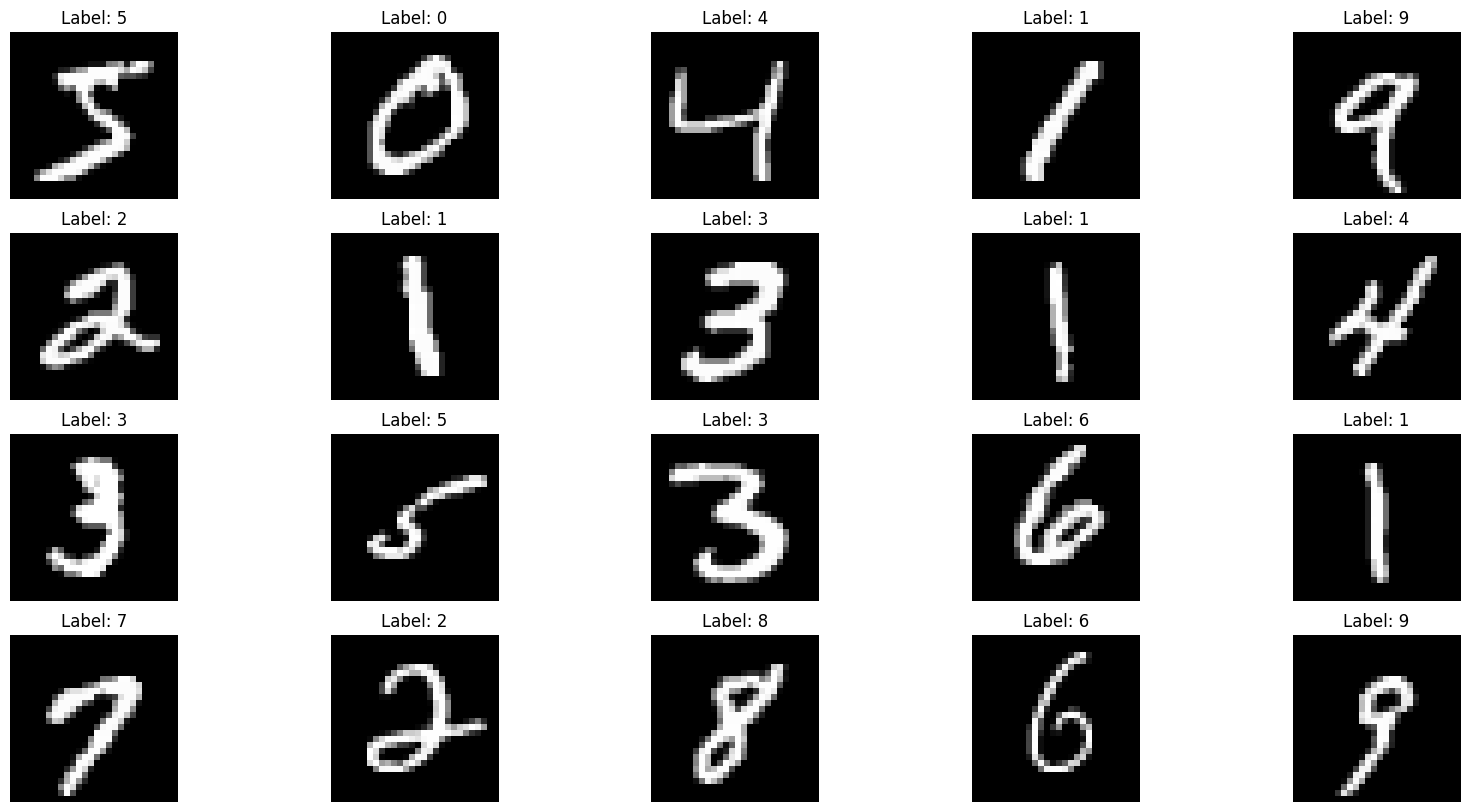

In [39]:
plt.figure(figsize=(20, 10))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.show()

In [40]:
model = Sequential([
    Flatten(input_shape=(28, 28)), 
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
    # why 10 ? cause we have 10 classes in the dataset (digits 0-9)
])

model.summary()

c:\Users\RED  LINE\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(optimizer = Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
callback = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True),
]
history = model.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=32, callbacks=callback)

Epoch 1/50
1485/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6924 - loss: 2.6068

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8084 - loss: 1.0398 - val_accuracy: 0.9147 - val_loss: 0.3266 - learning_rate: 0.0010
Epoch 2/50
1487/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9114 - loss: 0.3362

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9191 - loss: 0.3144 - val_accuracy: 0.9355 - val_loss: 0.2451 - learning_rate: 0.0010
Epoch 3/50
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9394 - loss: 0.2263

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9385 - loss: 0.2311 - val_accuracy: 0.9453 - val_loss: 0.2065 - learning_rate: 0.0010
Epoch 4/50
1472/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9462 - loss: 0.2022

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9450 - loss: 0.2059 - val_accuracy: 0.9480 - val_loss: 0.1954 - learning_rate: 0.0010
Epoch 5/50
1495/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9521 - loss: 0.1815

...

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9584 - loss: 0.1584 - val_accuracy: 0.9540 - val_loss: 0.1819 - learning_rate: 0.0010
Epoch 8/50
1483/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9628 - loss: 0.1426

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9609 - loss: 0.1476 - val_accuracy: 0.9558 - val_loss: 0.1784 - learning_rate: 0.0010
Epoch 9/50
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9647 - loss: 0.1351

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9631 - loss: 0.1433 - val_accuracy: 0.9575 - val_loss: 0.1646 - learning_rate: 0.0010
Epoch 10/50
1487/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9683 - loss: 0.1197

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9662 - loss: 0.1312 - val_accuracy: 0.9622 - val_loss: 0.1549 - learning_rate: 0.0010
Epoch 11/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9684 - loss: 0.1269 - val_accuracy: 0.9588 - val_loss: 0.1853 - learning_rate: 0.0010
Epoch 12/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9693 - loss: 0.1197 - val_accuracy: 0.9606 - val_loss: 0.1715 - learning_rate: 0.0010
Epoch 13/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9699 - loss: 0.1195 - val_accuracy: 0.9613 - val_loss: 0.1653 - learning_rate: 0.0010
Epoch 14/50
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9794 - loss: 0.0756

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9807 - loss: 0.0714 - val_accuracy: 0.9672 - val_loss: 0.1410 - learning_rate: 1.0000e-04
Epoch 15/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9836 - loss: 0.0588 - val_accuracy: 0.9672 - val_loss: 0.1432 - learning_rate: 1.0000e-04
Epoch 16/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9854 - loss: 0.0532 - val_accuracy: 0.9681 - val_loss: 0.1466 - learning_rate: 1.0000e-04
Epoch 17/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9863 - loss: 0.0482 - val_accuracy: 0.9678 - val_loss: 0.1491 - learning_rate: 1.0000e-04
Epoch 18/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9879 - loss: 0.0419 - val_accuracy: 0.9680 - val_loss: 0.1479 - learning_rate: 1.0000e-05
Epoch 19/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9877 - loss: 0.0415 - val_accuracy: 0.9680 - val_loss: 0.1484 - learning_rate: 1.0000e-05


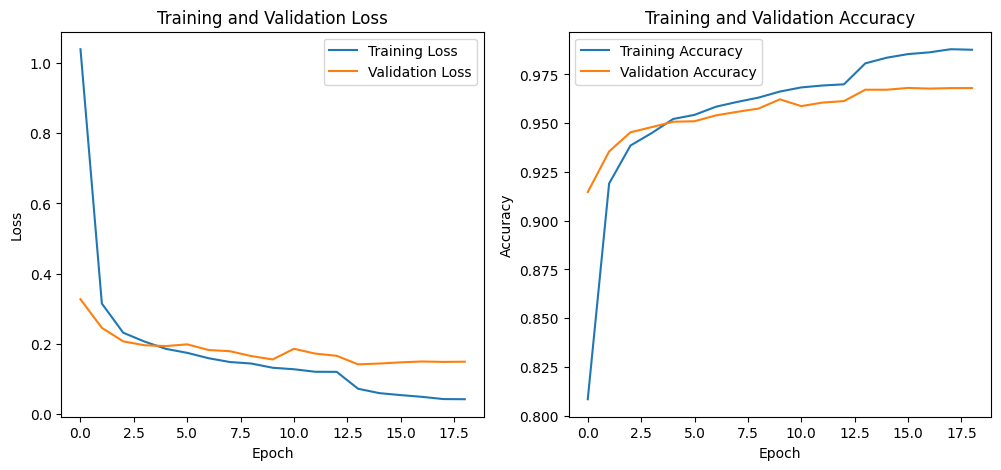

In [42]:
loss = history.history['loss']
loss_val = history.history['val_loss']
accuracy = history.history['accuracy']
accuracy_val = history.history['val_accuracy']


# want to make subplots for loss and accuracy
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss, label = 'Training Loss')
plt.plot(loss_val, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracy, label = 'Training Accuracy')
plt.plot(accuracy_val, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

In [43]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9651 - loss: 0.1518
Test Loss: 0.1518
Test Accuracy: 0.9651


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


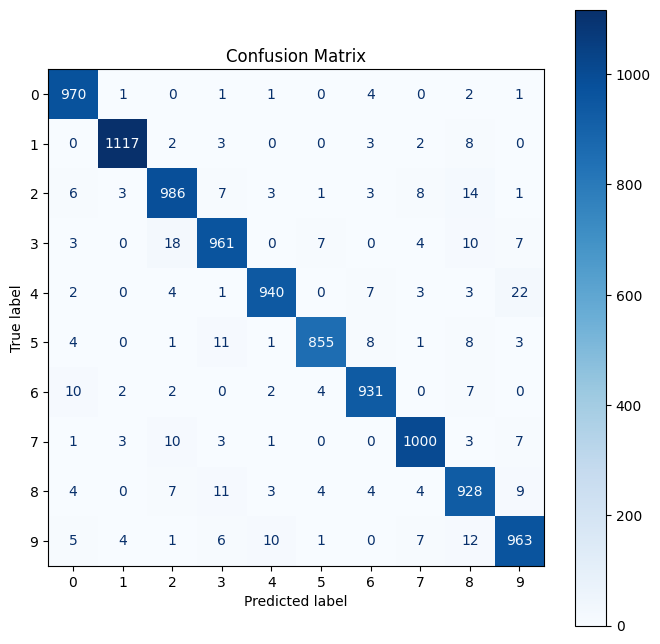

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_classes,
    display_labels=[str(i) for i in range(10)],  # digits 0–9
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title('Confusion Matrix')
plt.show()


In [ ]:
classification_report_model = classification_report(y_test, y_pred_classes)
print("Classification Report:\n")
print(classification_report_model)

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.98      0.99      1135
           2       0.96      0.96      0.96      1032
           3       0.96      0.95      0.95      1010
           4       0.98      0.96      0.97       982
           5       0.98      0.96      0.97       892
           6       0.97      0.97      0.97       958
           7       0.97      0.97      0.97      1028
           8       0.93      0.95      0.94       974
           9       0.95      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.96      0.96     10000
weighted avg       0.97      0.97      0.97     10000



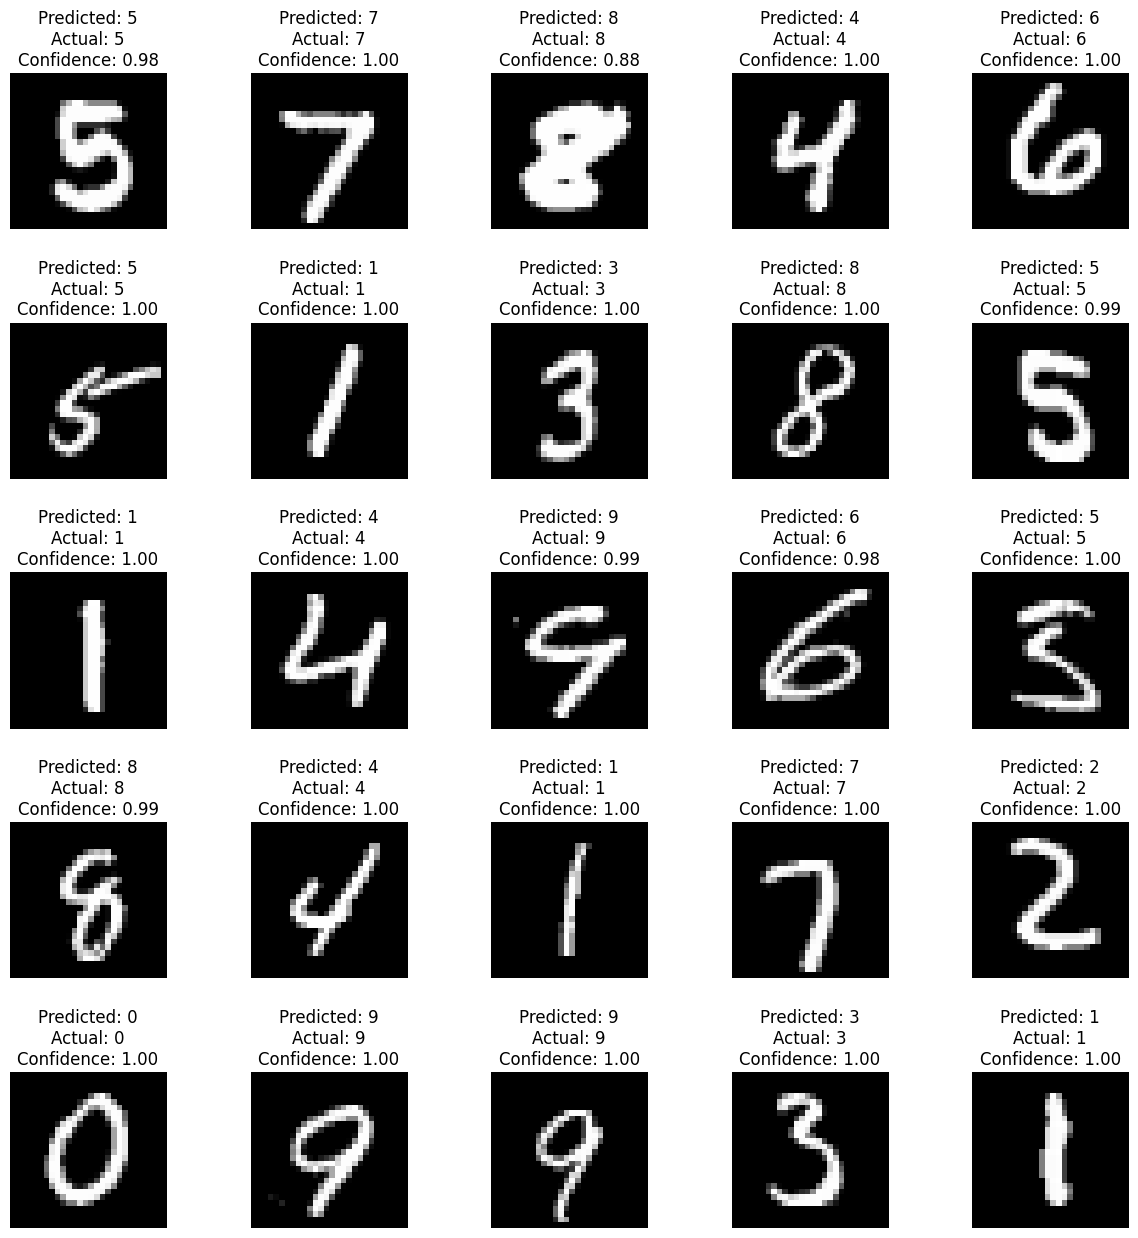

In [ ]:
plt.figure(figsize=(15, 15))
random_indices = random.sample(range(len(X_test)), 25)
for i, idx in enumerate(random_indices):
    plt.subplot(5, 5, i + 1)
    plt.subplots_adjust(hspace=0.6)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f'Predicted: {y_pred_classes[idx]}\nActual: {y_test[idx]}\nConfidence: {np.max(y_pred[idx]):.2f}')
    plt.axis('off')
plt.show()

# **If we add some Preprocessing Steps , Does it Affect ?**

In [85]:
augmentation_steps = tf.keras.Sequential([
    # tf.keras.layers.RandomRotation(0.1),
    # tf.keras.layers.RandomZoom(0.1),
    # tf.keras.layers.RandomTranslation(0.1, 0.1),
    # tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomContrast(0.05),
    # tf.keras.layers.RandomBrightness(0.1),
    # tf.keras.layers.RandomCrop(24, 24, input_shape=(28, 28, 1)),
    # tf.keras.layers.Resizing(32, 32),
])

In [86]:
model_with_augmentation = Sequential([
    augmentation_steps,
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model.summary()

c:\Users\RED  LINE\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,464 (1.08 MB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 188,310 (735.59 KB)

In [87]:
model_with_augmentation.compile(optimizer = Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_with_augmentation = model_with_augmentation.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=32, callbacks=callback)

Epoch 1/50


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7262 - loss: 2.7379 - val_accuracy: 0.8712 - val_loss: 0.5649 - learning_rate: 0.0010
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8263 - loss: 0.6300 - val_accuracy: 0.9097 - val_loss: 0.3870 - learning_rate: 0.0010
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8614 - loss: 0.5205 - val_accuracy: 0.9215 - val_loss: 0.3416 - learning_rate: 0.0010
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8994 - loss: 0.3537 - val_accuracy: 0.9392 - val_loss: 0.2460 - learning_rate: 1.0000e-04
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9121 - loss: 0.3020 - val_accuracy: 0.9441 - val_loss: 0.2386 - learning_rate: 1.0000e-04


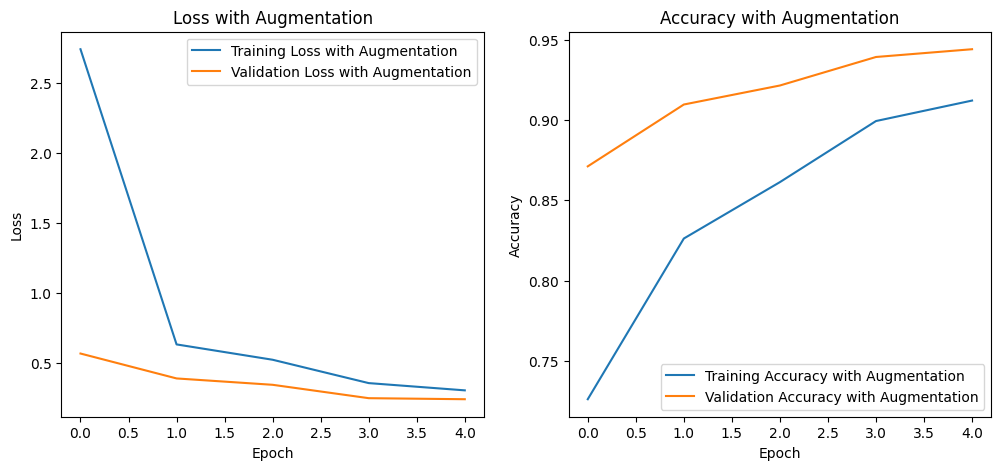

In [88]:
loss_aug = history_with_augmentation.history['loss']
loss_val_aug = history_with_augmentation.history['val_loss']
accuracy_aug = history_with_augmentation.history['accuracy']
accuracy_val_aug = history_with_augmentation.history['val_accuracy']

plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_aug, label = 'Training Loss with Augmentation')
plt.plot(loss_val_aug, label = 'Validation Loss with Augmentation')
plt.title('Loss with Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracy_aug, label = 'Training Accuracy with Augmentation')
plt.plot(accuracy_val_aug, label = 'Validation Accuracy with Augmentation')
plt.title('Accuracy with Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [89]:
test_loss_with_aug, test_accuracy_with_aug = model_with_augmentation.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss_with_aug:.4f}')
print(f'Test Accuracy: {test_accuracy_with_aug:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8664 - loss: 0.5819
Test Loss: 0.5819
Test Accuracy: 0.8664


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


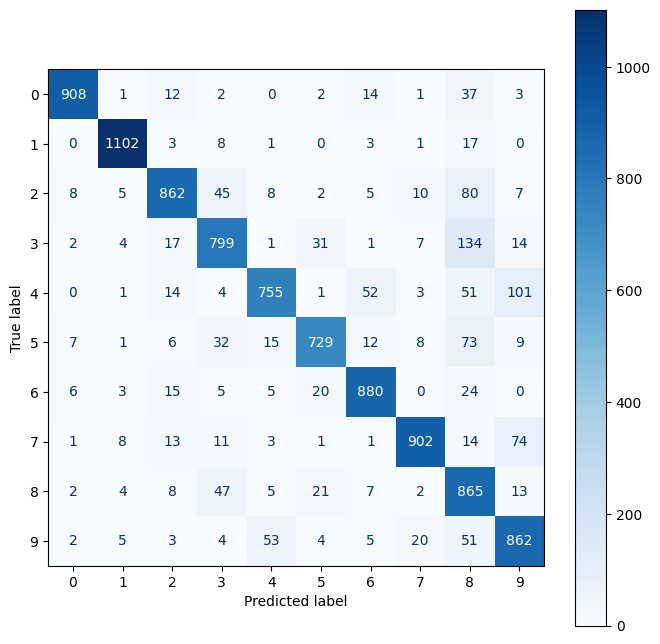

In [90]:
y_pred_aug = model_with_augmentation.predict(X_test)
y_pred_classes_aug = np.argmax(y_pred_aug, axis=1)

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_classes_aug,
    display_labels=[str(i) for i in range(10)],  # digits 0–9
    cmap=plt.cm.Blues,
    ax=ax
)

In [91]:
classification_report_model = classification_report(y_test, y_pred_classes_aug)
print("Classification Report:\n")
print(classification_report_model)

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       980
           1       0.97      0.97      0.97      1135
           2       0.90      0.84      0.87      1032
           3       0.83      0.79      0.81      1010
           4       0.89      0.77      0.83       982
           5       0.90      0.82      0.86       892
           6       0.90      0.92      0.91       958
           7       0.95      0.88      0.91      1028
           8       0.64      0.89      0.75       974
           9       0.80      0.85      0.82      1009

    accuracy                           0.87     10000
   macro avg       0.88      0.86      0.87     10000
weighted avg       0.88      0.87      0.87     10000



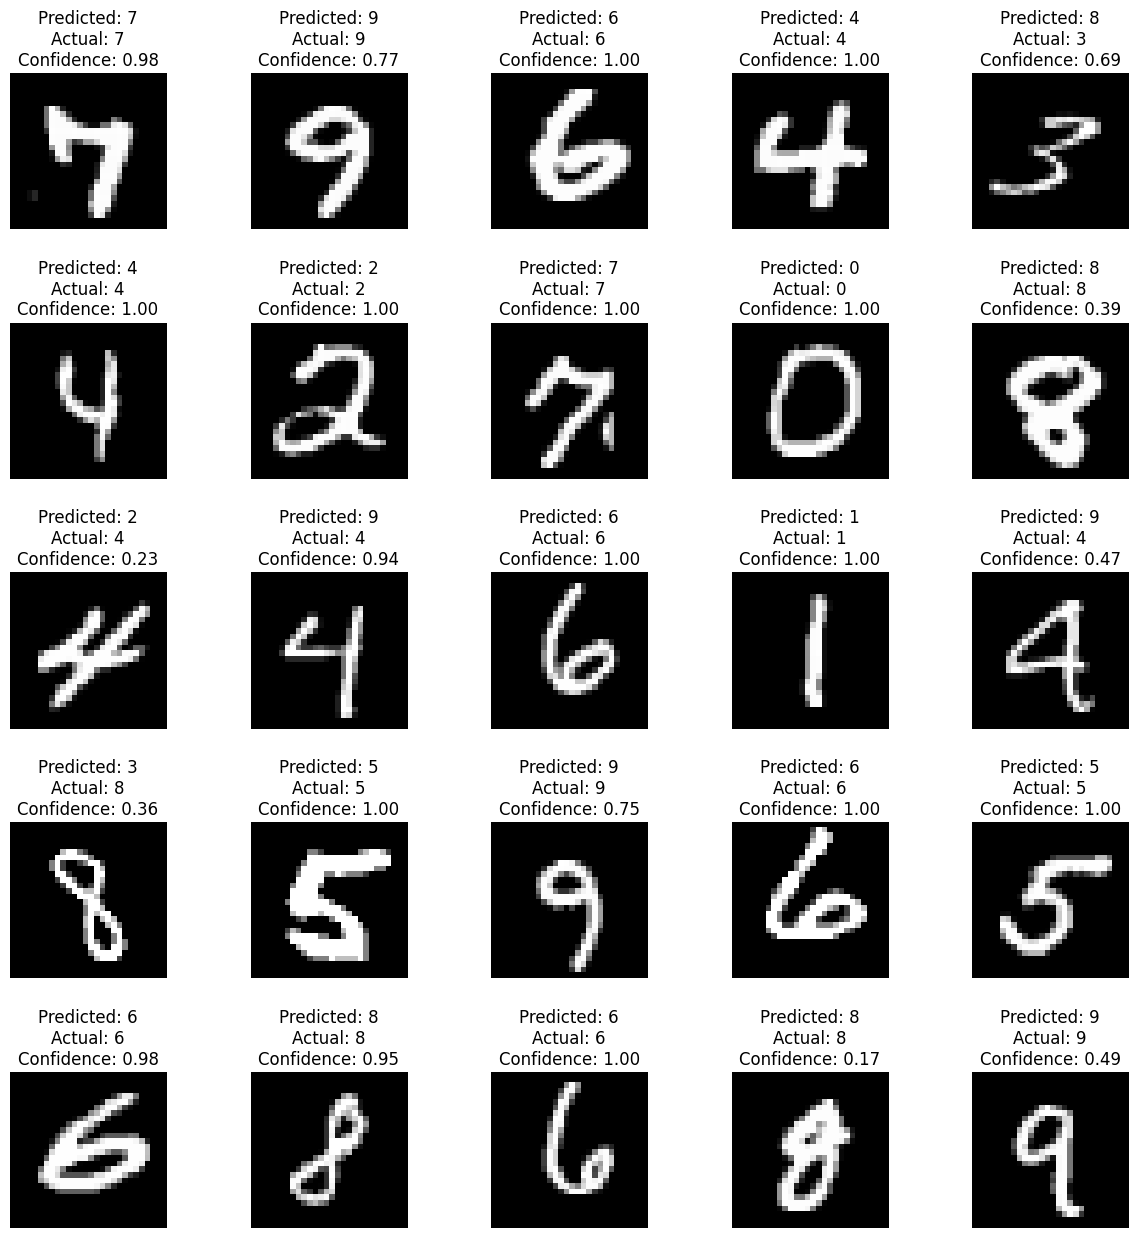

In [92]:
plt.figure(figsize=(15, 15))
random_indices = random.sample(range(len(X_test)), 25)
for i, idx in enumerate(random_indices):
    plt.subplot(5, 5, i + 1)
    plt.subplots_adjust(hspace=0.6)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f'Predicted: {y_pred_classes_aug[idx]}\nActual: {y_test[idx]}\nConfidence: {np.max(y_pred_aug[idx]):.2f}')
    plt.axis('off')
plt.show()